# Task IX - Kolmogorov-Arnold Network (KAN)

This task implements a classical Kolmogorov-Arnold Network (KAN) using basis-splines for MNIST classification, evaluates its performance, and discusses quantum KAN extension ideas.

## Steps
1. Implement a classical KAN for MNIST using basis-splines or similar.
2. Train and evaluate on MNIST test data.
3. Comment on quantum extension ideas and sketch quantum KAN architecture.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import BSpline
from sklearn.metrics import accuracy_score

In [ ]:
import os
os.makedirs('task9', exist_ok=True)
print("Directory 'task9' created successfully.")

Directory 'task8' created successfully.


100%|██████████| 9.91M/9.91M [00:00<00:00, 132MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 27.1MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 114MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.34MB/s]


Epoch 1 completed.
Epoch 2 completed.
Epoch 3 completed.
Epoch 4 completed.
Epoch 5 completed.
Epoch 6 completed.
Epoch 7 completed.
Epoch 8 completed.
KAN Test Accuracy: 0.8293


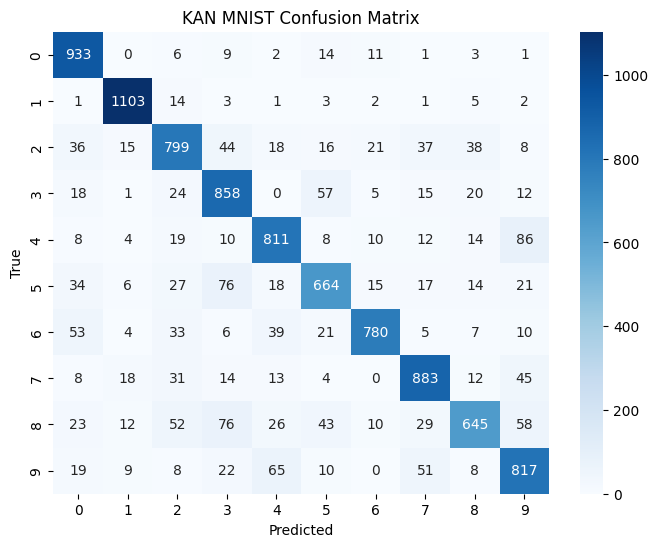

In [3]:
# Basis-spline layer for KAN
class BSplineLayer(nn.Module):
    def __init__(self, n_knots=8, degree=3):
        super().__init__()
        self.n_knots = n_knots
        self.degree = degree
        self.knots = nn.Parameter(torch.linspace(0, 1, n_knots))
        self.coeffs = nn.Parameter(torch.randn(n_knots))
    def forward(self, x):
        # Normalize input to [0,1]
        x_norm = (x - x.min()) / (x.max() - x.min() + 1e-8)
        x_np = x_norm.detach().cpu().numpy()
        spline = BSpline(self.knots.detach().cpu().numpy(), self.coeffs.detach().cpu().numpy(), self.degree)
        y = np.zeros_like(x_np)
        for i in range(x_np.shape[0]):
            for j in range(x_np.shape[1]):
                y[i, j] = spline(x_np[i, j])
        return torch.tensor(y, device=x.device, dtype=x.dtype)

class KAN(nn.Module):
    def __init__(self, input_dim=28*28, hidden_dim=128, n_knots=8, degree=3, num_classes=10):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.spline1 = BSplineLayer(n_knots, degree)
        self.fc2 = nn.Linear(hidden_dim, num_classes)
    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        x = self.spline1(x)
        x = self.fc2(x)
        return x

# Training and evaluation

def train_kan():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])
    trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
    testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
    trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)
    testloader = torch.utils.data.DataLoader(testset, batch_size=256, shuffle=False)

    model = KAN().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # Training
    for epoch in range(8):
        model.train()
        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
        print(f"Epoch {epoch+1} completed.")

    # Evaluation
    model.eval()
    correct, total = 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    acc = correct / total
    print(f"KAN Test Accuracy: {acc:.4f}")

    # Plot confusion matrix
    from sklearn.metrics import confusion_matrix
    import seaborn as sns
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('KAN MNIST Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.savefig('task9/kan_mnist_confusion.png')
    plt.show()
    # Save accuracy
    with open('task9/kan_mnist_results.txt', 'w') as f:
        f.write(f'KAN Test Accuracy: {acc:.4f}\n')

if __name__ == "__main__":
    train_kan()
